In [1]:
import os

base_path = "/kaggle/input/datasets/salader/dogsvscats"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print(train_path)
print(test_path)

/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/test


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input

In [9]:
# Generator to divide batches
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [4]:
# Normalize --> to values between 0 to 1
def process(image, label):
    image = tf.cast(image/255, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [5]:
# CNN Model
model = Sequential()

# Input Layer
model.add(Input(shape = (256, 256, 3)))

# Conv Layer 1
model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
# Max Pooling Layer 1
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
# Conv Layer 2
model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
# Max Pooling Layer 2
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
# Conv Layer 3
model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
# Max Pooling Layer 3
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

# Flatten Layer
model.add(Flatten())

# Dense/Fully Connected Layers
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# compile model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [10]:
history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.5937 - loss: 1.1963 - val_accuracy: 0.6284 - val_loss: 0.6453
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.6748 - loss: 0.5978 - val_accuracy: 0.6368 - val_loss: 0.6468
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.7623 - loss: 0.4917 - val_accuracy: 0.6276 - val_loss: 0.7417
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8266 - loss: 0.3772 - val_accuracy: 0.6168 - val_loss: 0.9678
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.8824 - loss: 0.2671 - val_accuracy: 0.6064 - val_loss: 1.3898
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9133 - loss: 0.2204 - val_accuracy: 0.6074 - val_loss: 1.3443
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9395 - loss: 0.1685 - val_accuracy: 0.6058 - val_loss: 1.6228
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9506 - loss: 0.1416 - 

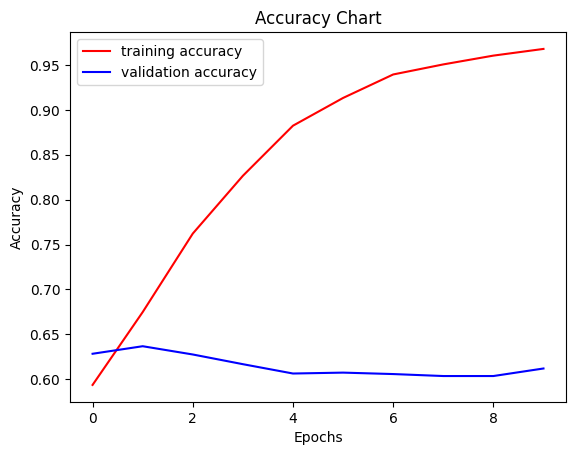

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'red', label = 'training accuracy')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Accuracy Chart')
plt.legend()
plt.show()

In [12]:
# Model is OverFitting

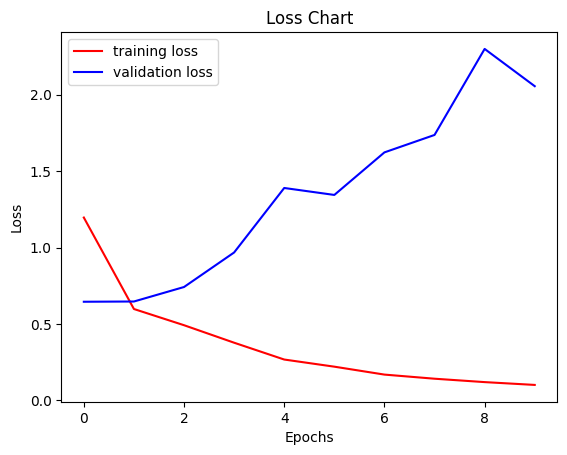

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color = 'red', label = 'training loss')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Loss Chart')
plt.legend()
plt.show()

In [14]:
# training loss reducing but validation loss incresing with epoch
# clear sign of overfitting

### Ways to Redunce Overfitting :
1. Add more data
2. Data Augmentation
3. L1/L2 Regularization
4. Dropouts
5. Batch Normalization
6. Reduce Complexity of Model

In [15]:
from keras.layers import Dropout, BatchNormalization

In [20]:
# CNN Model
model2 = Sequential()

# Input Layer
model2.add(Input(shape = (256, 256, 3)))

# Conv Layer 1
model2.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model2.add(BatchNormalization())
# Max Pooling Layer 1
model2.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model2.add(BatchNormalization())
# Conv Layer 2
model2.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model2.add(BatchNormalization())
# Max Pooling Layer 2
model2.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
# Conv Layer 3
model2.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model2.add(BatchNormalization())
# Max Pooling Layer 3
model2.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

# Flatten Layer
model2.add(Flatten())

# Dense/Fully Connected Layers
model2.add(Dense(128, activation = 'relu'))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation = 'relu'))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation = 'sigmoid'))

In [21]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,321 (56.64 MB)

 Trainable params: 14,847,809 (56.64 MB)

 Non-trainable params: 512 (2.00 KB)

In [22]:
model2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [23]:
history2 = model2.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5533 - loss: 1.4081 - val_accuracy: 0.6384 - val_loss: 0.6271
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6291 - loss: 0.6493 - val_accuracy: 0.7034 - val_loss: 0.5928
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.6866 - loss: 0.5765 - val_accuracy: 0.7228 - val_loss: 0.5245
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7495 - loss: 0.5014 - val_accuracy: 0.7260 - val_loss: 0.5476
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7865 - loss: 0.4477 - val_accuracy: 0.7304 - val_loss: 0.5610
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8179 - loss: 0.3988 - val_accuracy: 0.8022 - val_loss: 0.4265
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8376 - loss: 0.3653 - val_accuracy: 0.7842 - val_loss: 0.4817
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8591 - loss: 0.3183 - 

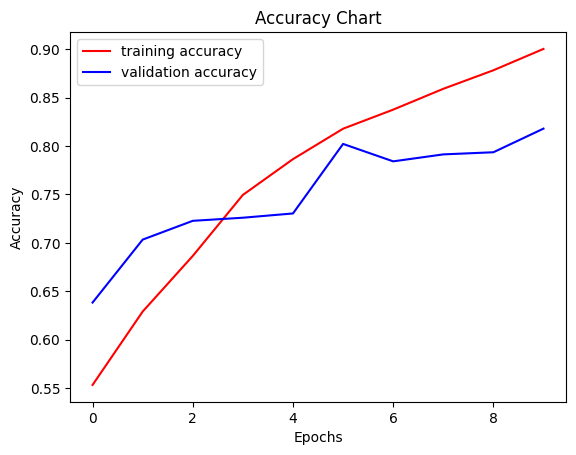

In [24]:
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'], color = 'red', label = 'training accuracy')
plt.plot(history2.history['val_accuracy'], color = 'blue', label = 'validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Accuracy Chart')
plt.legend()
plt.show()

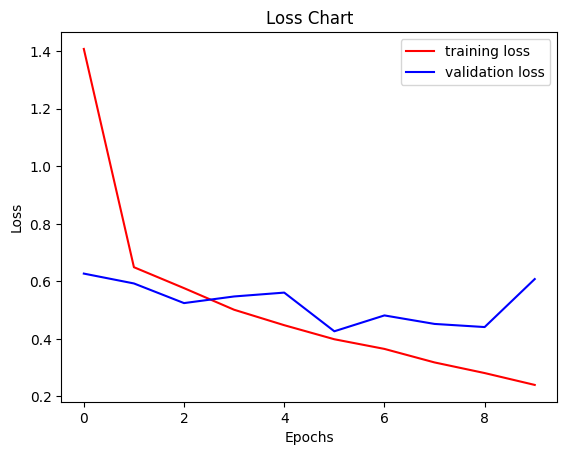

In [25]:
import matplotlib.pyplot as plt
plt.plot(history2.history['loss'], color = 'red', label = 'training loss')
plt.plot(history2.history['val_loss'], color = 'blue', label = 'validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Loss Chart')
plt.legend()
plt.show()

## Prediction

In [62]:
import cv2

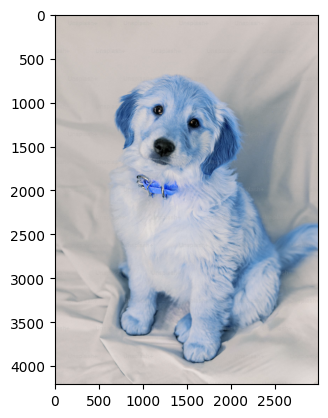

In [63]:
test_img = cv2.imread('/kaggle/input/datasets/anirbanmaitra/puppy-image/dog.avif')
plt.imshow(test_img)

In [64]:
test_img.shape

(4206, 3000, 3)

In [65]:
test_img = cv2.resize(test_img, (256, 256))

In [66]:
# make a batch of the image
test_input = test_img.reshape((1, 256, 256, 3)) #1 image of dimension (246, 256, 3)

In [67]:
model2.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.24090204]], dtype=float32)

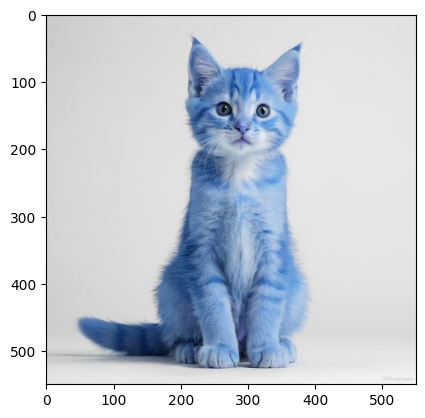

In [68]:
test_img = cv2.imread('/kaggle/input/datasets/anirbanmaitra/puppy-image/cat.jpg')
plt.imshow(test_img)

In [69]:
test_img = cv2.resize(test_img, (256, 256))
# make a batch of the image
test_input = test_img.reshape((1, 256, 256, 3)) #1 image of dimension (246, 256, 3)
# predict
model2.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.0309459]], dtype=float32)